In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

POSITIONS_DATASET_PATH = "/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/users_positions/yb_tokens_positions.csv"
# POSITIONS_DATASET_PATH = "/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/users_positions/pt_tokens_positions.csv"

OUTPUT_PATH = "/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/user_positions_clustered.csv"

BEHAVIOR_FEATURES = [
    'open_ltv',
    'max_ltv',
    'open_debt',
    'position_size_share_open',
    'position_size_share_max',
    'duration_hours',
    # 'n_actions_total',
    # 'n_repays',
    # 'n_borrows',
    'avg_repay_ratio',
    # 'time_to_first_action',
    # 'avg_time_between_actions',
    'avg_borrow_rate_position'
]

def load_positions(filepath):
    df = pd.read_csv(filepath)
    df['open_datetime'] = pd.to_datetime(df['open_datetime'])
    df['close_datetime'] = pd.to_datetime(df['close_datetime'])
    df = df[~df['close_datetime'].isna()].fillna(0)
    # print(df.isna().sum())
    return df

def prepare_features(df, feature_list):
    X = df[feature_list].copy()
    X = X.replace([np.inf, -np.inf], np.nan)
    
    if 'time_to_first_action' in df.columns:
        df['time_to_first_action'] = np.log1p(df['time_to_first_action'])
    if 'avg_time_between_actions' in df.columns:
        df['avg_time_between_actions'] = np.log1p(df['avg_time_between_actions'])
    if 'duration_hours' in df.columns:
        df['duration_hours'] = np.log1p(df['duration_hours'])
    if 'open_debt' in df.columns:
        df['open_debt'] = np.log1p(df['open_debt'])

    # X = X[~X['close_datetime'].isna()]
    return X, X.index

def standardize_features(X):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    return X_scaled, scaler

def evaluate_kmeans(X_scaled, k_range=range(4, 7)):
    results = {}
    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(X_scaled)
        score = silhouette_score(X_scaled, labels)
        results[k] = {
            'model': kmeans,
            'labels': labels,
            'silhouette': score
        }
    return results

from sklearn.mixture import GaussianMixture
from sklearn.cluster import AgglomerativeClustering, DBSCAN, SpectralClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import numpy as np
import hdbscan
from tqdm import tqdm
def evaluate_gmm(X_scaled, n_components_range=range(4, 7), covariance_type='diag', random_state=42):
    results = {}
    for n in tqdm(n_components_range):
        gmm = GaussianMixture(n_components=n, covariance_type=covariance_type, 
                              random_state=random_state, n_init=5)
        labels = gmm.fit_predict(X_scaled)
        if len(np.unique(labels)) > 1:
            score = silhouette_score(X_scaled, labels)
        else:
            score = -1.0
        results[n] = {
            'model': gmm,
            'labels': labels,
            'silhouette': score
        }
    return results

def evaluate_hdbscan(X_scaled, min_cluster_size_range=[10, 25, 50], min_samples=None, metric='euclidean'):
    results = {}
    for mcs in min_cluster_size_range:
        clusterer = hdbscan.HDBSCAN(min_cluster_size=mcs, min_samples=min_samples, 
                                    metric=metric, gen_min_span_tree=True)
        labels = clusterer.fit_predict(X_scaled)
        unique_labels = np.unique(labels)
        n_clusters = len(unique_labels[unique_labels >= 0])
        if n_clusters > 1:
            core_samples_mask = np.zeros_like(labels, dtype=bool)
            core_samples_mask[clusterer.labels_ == -1] = False
            if np.sum(core_samples_mask) > 0:
                try:
                    score = silhouette_score(X_scaled[core_samples_mask], labels[core_samples_mask])
                except:
                    score = -1.0
            else:
                score = -1.0
        else:
            score = -1.0
        results[f"mcs_{mcs}"] = {
            'model': clusterer,
            'labels': labels,
            'silhouette': score,
            'n_clusters': n_clusters,
            'noise_ratio': np.sum(labels == -1) / len(labels)
        }
    return results

def evaluate_agglomerative(X_scaled, n_clusters_range=range(4, 7), linkage='ward'):
    results = {}
    for k in n_clusters_range:
        agg = AgglomerativeClustering(n_clusters=k, linkage=linkage)
        labels = agg.fit_predict(X_scaled)
        if len(np.unique(labels)) > 1:
            score = silhouette_score(X_scaled, labels)
        else:
            score = -1.0
        results[k] = {
            'model': agg,
            'labels': labels,
            'silhouette': score
        }
    return results

def evaluate_spectral(X_scaled, n_clusters_range=range(4, 7), affinity='rbf', random_state=42):
    results = {}
    for k in n_clusters_range:
        spec = SpectralClustering(n_clusters=k, affinity=affinity, 
                                  random_state=random_state, assign_labels='kmeans')
        labels = spec.fit_predict(X_scaled)
        if len(np.unique(labels)) > 1:
            score = silhouette_score(X_scaled, labels)
        else:
            score = -1.0
        results[k] = {
            'model': spec,
            'labels': labels,
            'silhouette': score
        }
    return results

def evaluate_dbscan(X_scaled, eps_range=None, min_samples_range=None):
    if eps_range is None:
        eps_range = np.linspace(0.1, 2.0, 10)
    if min_samples_range is None:
        min_samples_range = [3, 5, 10]
    results = {}
    best_score = -1.0
    best_params = None
    for eps in eps_range:
        for min_samp in min_samples_range:
            db = DBSCAN(eps=eps, min_samples=min_samp, metric='euclidean')
            labels = db.fit_predict(X_scaled)
            n_clusters = len(np.unique(labels[labels >= 0]))
            if n_clusters > 1:
                core_mask = labels != -1
                if np.sum(core_mask) > 1:
                    try:
                        score = silhouette_score(X_scaled[core_mask], labels[core_mask])
                    except:
                        score = -1.0
                else:
                    score = -1.0
            else:
                score = -1.0
            key = f"eps_{eps:.3f}_ms_{min_samp}"
            results[key] = {
                'eps': eps,
                'min_samples': min_samp,
                'labels': labels,
                'silhouette': score,
                'n_clusters': n_clusters,
                'noise_ratio': np.sum(labels == -1) / len(labels)
            }
            if score > best_score:
                best_score = score
                best_params = key
    results['best_params'] = best_params
    return results

def add_cluster_labels(df, valid_idx, labels, k):
    df_clustered = df.copy()
    df_clustered['cluster'] = np.nan
    df_clustered.loc[valid_idx, 'cluster'] = labels.astype(int)
    df_clustered['cluster_k'] = k
    return df_clustered


In [113]:
# hdbscan_results = evaluate_hdbscan(X_scaled, min_cluster_size_range=[10, 25, 50])
# best_hdbscan_key = max(hdbscan_results.keys(), key=lambda k: hdbscan_results[k]['silhouette'] if isinstance(hdbscan_results[k], dict) else -1)
# hdbscan_labels = hdbscan_results[best_hdbscan_key]['labels']

gmm_results = evaluate_gmm(X_scaled, n_components_range=range(2, 7))
best_gmm_k = max(gmm_results.keys(), key=lambda k: gmm_results[k]['silhouette'])
gmm_labels = gmm_results[best_gmm_k]['labels']

for k, res in gmm_results.items():
    print(f"  k={k}: {res['silhouette']:.4f}")
print(f"\nBest k={best_gmm_k} with silhouette={gmm_results['silhouette']:.4f}")


100%|██████████| 5/5 [00:03<00:00,  1.41it/s]

  k=2: 0.5337
  k=3: 0.1362
  k=4: 0.1319
  k=5: 0.0917
  k=6: 0.0777


KeyError: 'silhouette'

In [125]:
for k in dbscan_results:
    print(f"{k} - {dbscan_results[k]['silhouette']}, {pd.Series(dbscan_results[k]['labels']).value_counts().values[:10]}")

eps_0.100_ms_3 - 0.7367464097347022, [4068   20   18   14   12   12   12   11   10   10]
eps_0.100_ms_5 - 0.7277594574206679, [4363   20   18   14   12   12   12   11   10   10]
eps_0.100_ms_10 - 0.8319931239492905, [4609   20   18   12   12   10   10   10   10   10]
eps_0.311_ms_3 - -0.2271031236486445, [2491 1462   46   42   20   18   16   15   14   14]
eps_0.311_ms_5 - -0.23352618427231275, [2491 1731   46   42   20   18   16   15   14   14]
eps_0.311_ms_10 - -0.21165651756535092, [2323 2145   46   42   18   15   14   12   12   10]
eps_0.522_ms_3 - -0.2001291306931483, [3657  618  104   20   18   16   12   12   10    8]
eps_0.522_ms_5 - -0.07690489286726707, [3657  802  104   20   18   16   12   12   10    8]
eps_0.522_ms_10 - 0.3246438385918535, [3585  978   96   20   18   14   10]
eps_0.733_ms_3 - 0.14769712310003447, [4085  306  138   22   12   10    8    8    8    8]
eps_0.733_ms_5 - 0.1458198752593711, [4085  358  138   22   12   10    8    8    8    8]
eps_0.733_ms_10 - 0.6680

TypeError: string indices must be integers

In [117]:
pd.Series(dbscan_results['eps_1.789_ms_5']['labels']).value_counts()

 0    4593
-1      98
 4       7
 1       6
 2       6
 3       6
 5       5
Name: count, dtype: int64

In [123]:
dbscan_results = evaluate_dbscan(X_scaled)
best_dbs_k = max(dbscan_results.keys(), key=lambda k: dbscan_results[k]['silhouette'])
gmm_labels = dbscan_results[best_dbs_k]['labels']

for k, res in dbscan_results.items():
    print(f"  k={k}: {res['silhouette']:.4f}")
print(f"\nBest k={best_dbs_k} with silhouette={dbscan_results['silhouette']:.4f}")


TypeError: string indices must be integers

In [121]:
df = load_positions(POSITIONS_DATASET_PATH)
X_clean, valid_idx = prepare_features(df, BEHAVIOR_FEATURES)
X_scaled, scaler = standardize_features(X_clean)

clustering_results = evaluate_kmeans(X_scaled, k_range=range(4, 15))

best_k = max(clustering_results.keys(), key=lambda k: clustering_results[k]['silhouette'])
best_result = clustering_results[best_k]

# df_final = add_cluster_labels(df, valid_idx, best_result['labels'], best_k)

# clustering_results = evaluate_agglomerative(X_scaled, n_clusters_range=range(4, 15))

# best_k = max(clustering_results.keys(), key=lambda k: clustering_results[k]['silhouette'])
# best_result = clustering_results[best_k]



best_k=6
df_final = add_cluster_labels(df, valid_idx, best_result['labels'], best_k)


print("Clustering completed.")
print(f"Number of valid samples after dropping NaNs: {len(valid_idx)}")
print("\nSilhouette scores:")
for k, res in clustering_results.items():
    print(f"  k={k}: {res['silhouette']:.4f}")
print(f"\nBest k={best_k} with silhouette={best_result['silhouette']:.4f}")


Clustering completed.
Number of valid samples after dropping NaNs: 4721

Silhouette scores:
  k=4: 0.5625
  k=5: 0.3079
  k=6: 0.3475
  k=7: 0.3579
  k=8: 0.2859
  k=9: 0.2711
  k=10: 0.2816
  k=11: 0.2851
  k=12: 0.2926
  k=13: 0.2645
  k=14: 0.2992

Best k=6 with silhouette=0.5625


In [122]:
len(clustering_results[7]['labels'])
df_final['cluster'].value_counts()
for i in clustering_results.keys():
    print(i)
    print(pd.Series(clustering_results[i]['labels']).value_counts().values)


4
[4231  342  146    2]
5
[3593  800  324    2    2]
6
[3467  780  322  148    2    2]
7
[3469  786  318  140    4    2    2]
8
[2411 1118  750  300  134    4    2    2]
9
[2117 1392  722  288  134   60    4    2    2]
10
[1979 1138  670  484  248  134   60    4    2    2]
11
[1729 1138  780  464  242  170  130   60    4    2    2]
12
[1709 1082  754  448  242  204  164   60   50    4    2    2]
13
[1474 1212  748  440  265  242  164  126   40    4    2    2    2]
14
[1769 1012  756  464  242  204  164   50   46    4    4    2    2    2]


In [79]:
df_final['cluster'].value_counts()

cluster
0.0    13337
2.0      996
1.0      314
4.0      251
5.0        2
3.0        2
Name: count, dtype: int64

In [78]:
# len(clustering_results[7]['labels'])
# df_final['cluster'].value_counts()
# for i in clustering_results.keys():
#     print(i)
#     print(pd.Series(clustering_results[i]['labels']).value_counts())
# # pd.Series([len(clustering_results[i]['labels']) for i in clustering_results.keys()]).value_counts()
# # X_scaled

def evaluate_all_clustering_methods(X_scaled, 
                                   kmeans_k_range=range(4, 8),
                                   gmm_n_range=range(4, 8),
                                   agg_n_range=range(4, 8),
                                   spectral_n_range=range(4, 8),
                                   hdbscan_min_cluster_sizes=[10, 25, 50],
                                   dbscan_eps_range=None,
                                   dbscan_min_samples_range=[3, 5, 10]):
    results_list = []
    
    print("")
    kmeans_results = evaluate_kmeans(X_scaled, kmeans_k_range)
    for k, res in kmeans_results.items():
        if isinstance(res, dict):
            labels = res['labels']
            results_list.append({
                'method': 'KMeans', 'param': f'k={k}', 'n_clusters': len(np.unique(labels)),
                'silhouette': res['silhouette'], 'cluster_sizes': pd.Series(labels).value_counts().tolist()
            })
    
    print("evaluate_agglomerative")
    agg_results = evaluate_agglomerative(X_scaled, agg_n_range)
    for k, res in agg_results.items():
        if isinstance(res, dict):
            labels = res['labels']
            results_list.append({
                'method': 'Agglomerative', 'param': f'k={k}', 'n_clusters': len(np.unique(labels)),
                'silhouette': res['silhouette'], 'cluster_sizes': pd.Series(labels).value_counts().tolist()
            })
    
    # print("evaluate_spectral")
    # spectral_results = evaluate_spectral(X_scaled, spectral_n_range)
    # for k, res in spectral_results.items():
    #     if isinstance(res, dict):
    #         labels = res['labels']
    #         results_list.append({
    #             'method': 'Spectral', 'param': f'k={k}', 'n_clusters': len(np.unique(labels)),
    #             'silhouette': res['silhouette'], 'cluster_sizes': pd.Series(labels).value_counts().tolist()
    #         })
    
    # print("evaluate_hdbscan")
    # hdbscan_results = evaluate_hdbscan(X_scaled, hdbscan_min_cluster_sizes)
    # for key, res in hdbscan_results.items():
    #     if isinstance(res, dict) and key != 'best_params':
    #         labels = res['labels']
    #         results_list.append({
    #             'method': 'HDBSCAN', 'param': key, 'n_clusters': res['n_clusters'],
    #             'silhouette': res['silhouette'], 'cluster_sizes': pd.Series(labels[labels != -1]).value_counts().tolist(),
    #             'noise_ratio': res['noise_ratio']
    #         })

    print("evaluate_dbscan")
    dbscan_results = evaluate_dbscan(X_scaled, dbscan_eps_range, dbscan_min_samples_range)
    for key, res in dbscan_results.items():
        if isinstance(res, dict):
            labels = res['labels']
            results_list.append({
                'method': 'DBSCAN', 'param': key, 'n_clusters': res['n_clusters'],
                'silhouette': res['silhouette'], 'cluster_sizes': pd.Series(labels[labels != -1]).value_counts().tolist(),
                'noise_ratio': res['noise_ratio']
            })
    
    # print("evaluate_gmm")
    # gmm_results = evaluate_gmm(X_scaled, gmm_n_range)
    # for n, res in gmm_results.items():
    #     if isinstance(res, dict):
    #         labels = res['labels']
    #         results_list.append({
    #             'method': 'GMM', 'param': f'n={n}', 'n_clusters': len(np.unique(labels)),
    #             'silhouette': res['silhouette'], 'cluster_sizes': pd.Series(labels).value_counts().tolist()
    #         })
    
    
    
    return pd.DataFrame(results_list)

# evaluate_all_clustering_methods(X_scaled)

CLUSTER DESCRIPTIVE STATISTICS

--- Cluster 0 (n=78) ---
  open_ltv                      : mean=    0.7491  median=    0.7992  std=    0.1241
  max_ltv                       : mean=    0.7556  median=    0.8009  std=    0.1270
  position_size_share_open      : mean=    0.0065  median=    0.0001  std=    0.0324
  position_size_share_max       : mean=    0.0088  median=    0.0001  std=    0.0354
  duration_hours                : mean= 3193.5543  median= 3172.0433  std=  457.0014
  n_actions_total               : mean=    1.4103  median=    1.0000  std=    1.4182
  n_repays                      : mean=    1.3333  median=    1.0000  std=    1.2344
  n_borrows                     : mean=    0.0769  median=    0.0000  std=    0.3129
  avg_repay_ratio               : mean=    0.9390  median=    1.0292  std=    0.2267
  time_to_first_action          : mean= 3181.6709  median= 3171.0383  std=  465.9684
  avg_borrow_rate_position      : mean=    0.0843  median=    0.0823  std=    0.0180

--- Clu

/var/folders/hj/pbs977kd43s6n1l9z3mxrj200000gn/T/ipykernel_82833/2662646321.py:144: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cluster_df[feat] = np.exp(cluster_df[feat])
/var/folders/hj/pbs977kd43s6n1l9z3mxrj200000gn/T/ipykernel_82833/2662646321.py:144: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cluster_df[feat] = np.exp(cluster_df[feat])
/var/folders/hj/pbs977kd43s6n1l9z3mxrj200000gn/T/ipykernel_82833/2662646321.py:144: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a

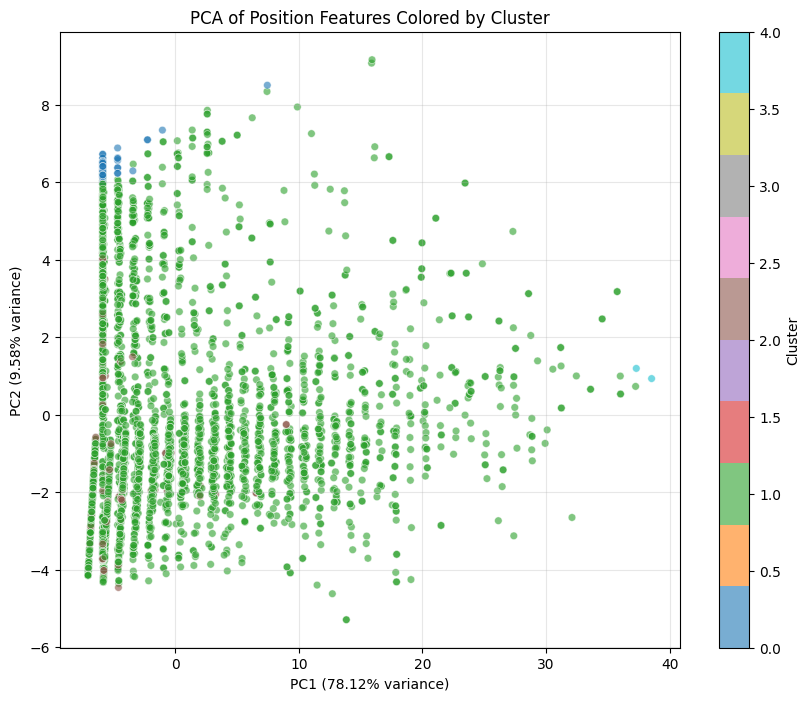

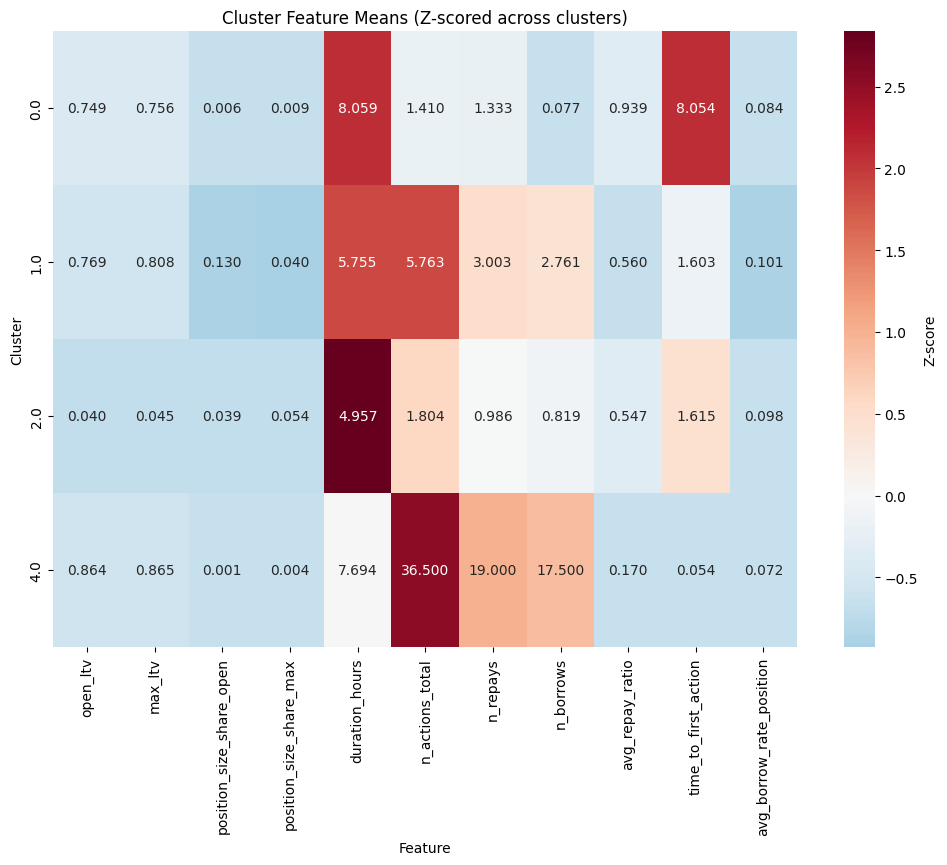

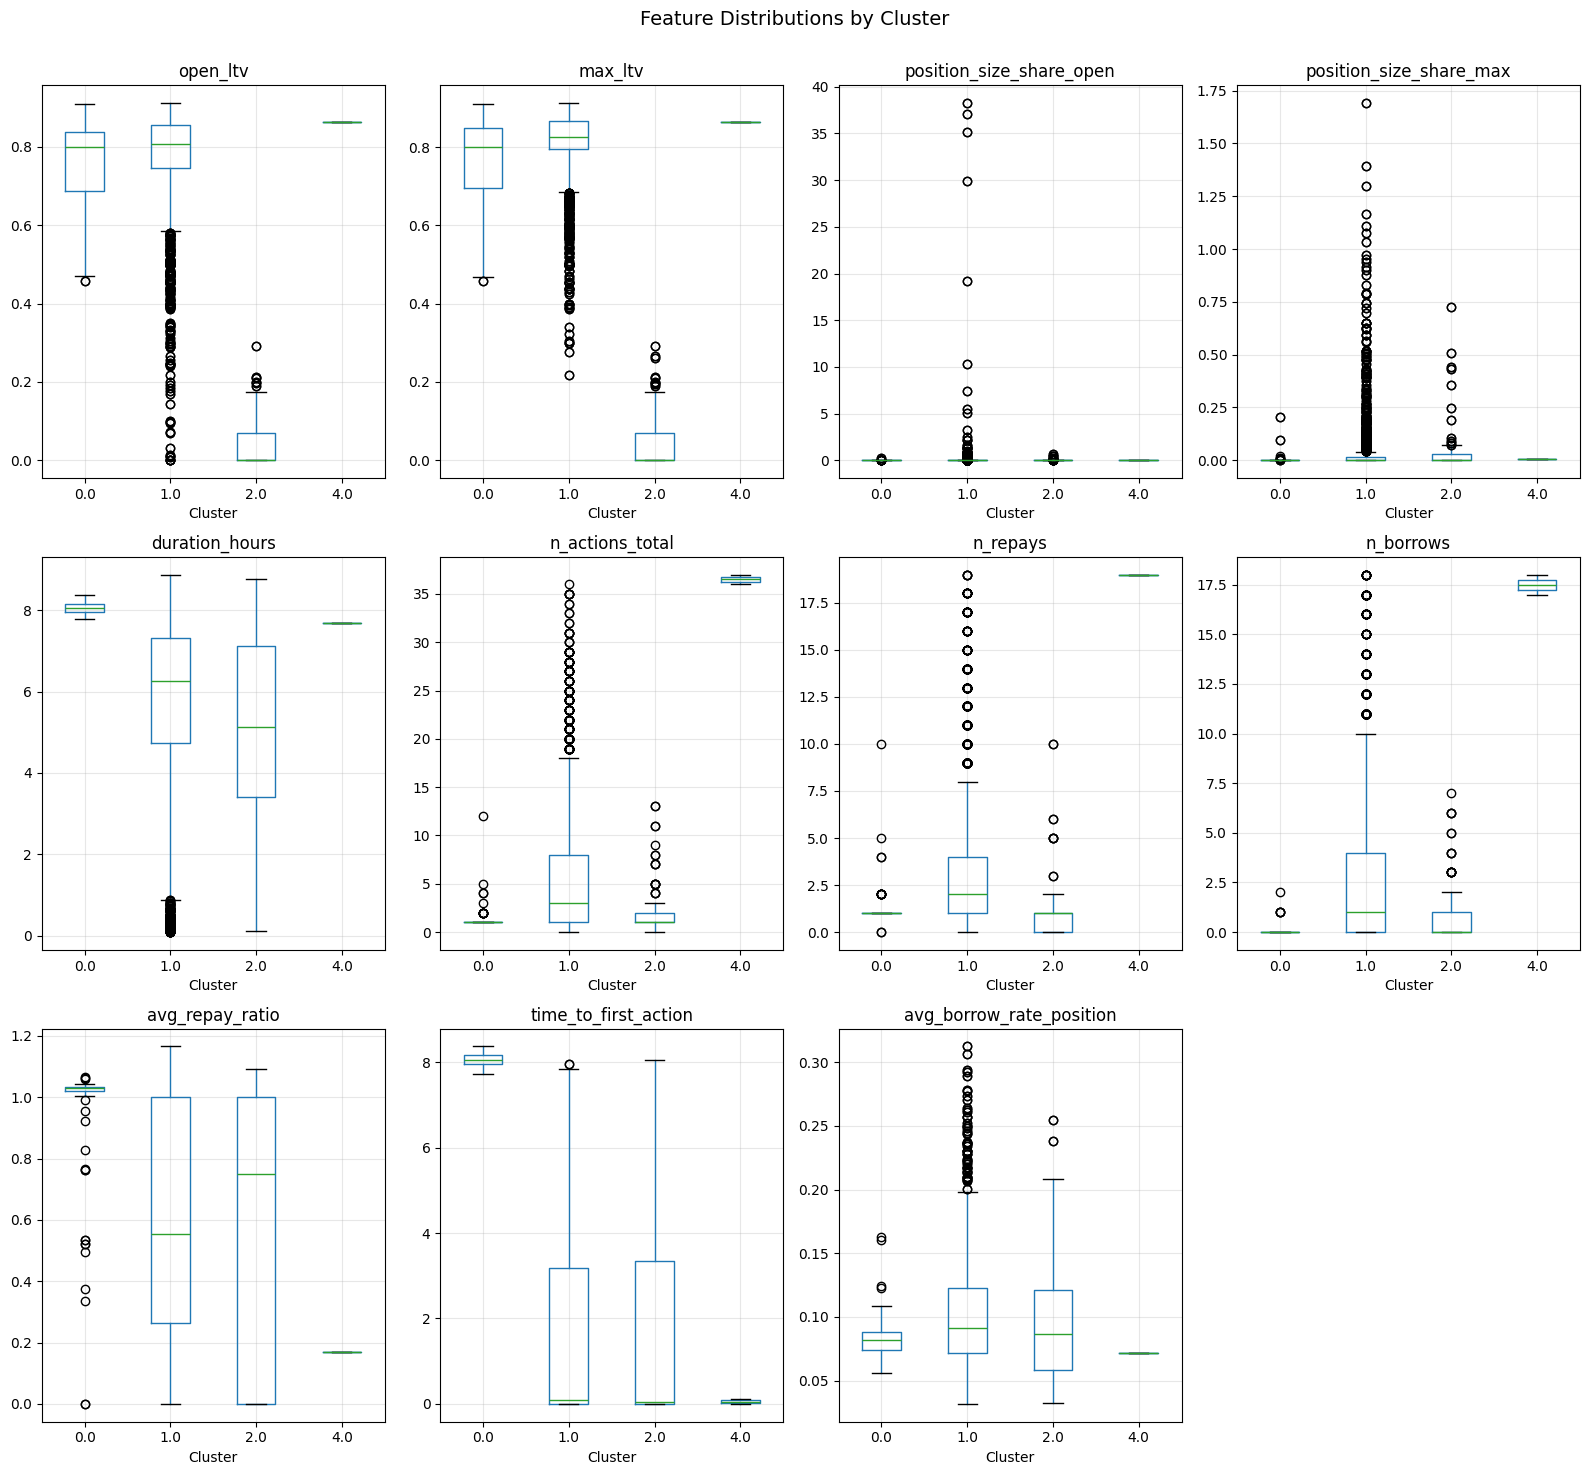

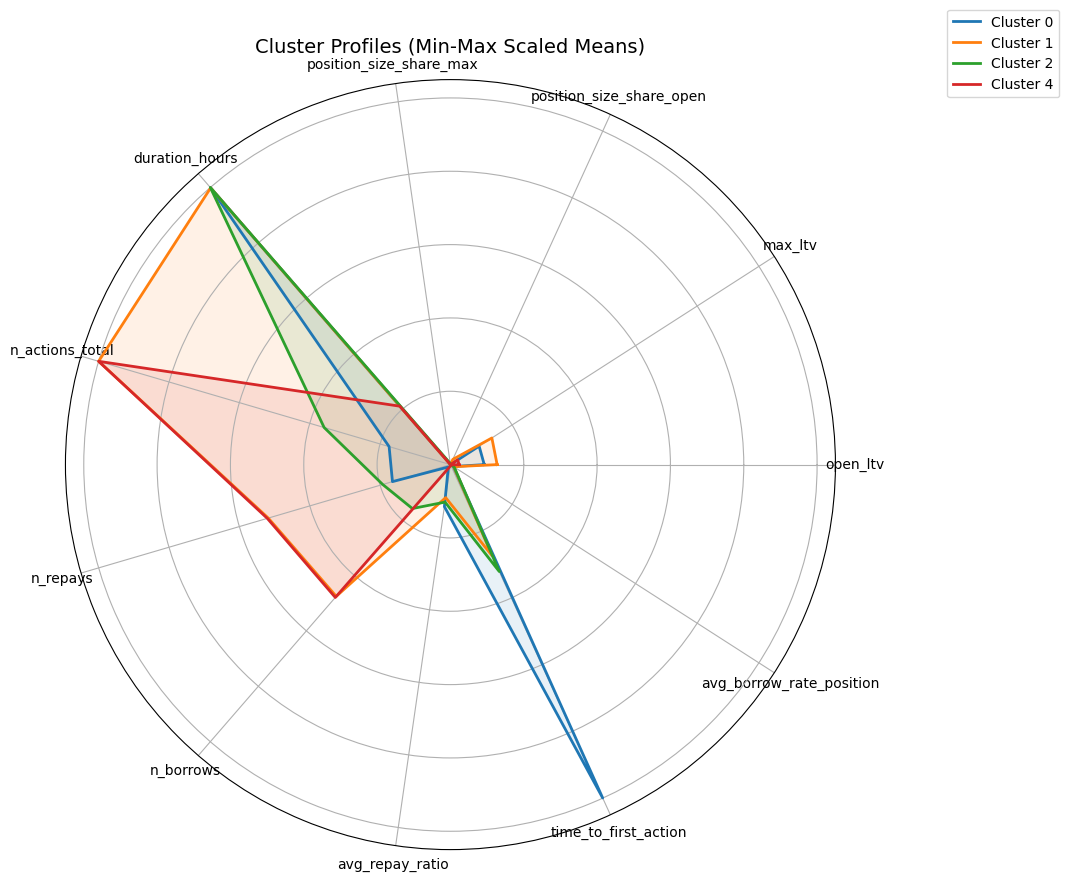

In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA


def load_clustered_data(filepath):
    df = pd.read_csv(filepath)
    return df

def plot_pca_clusters(df, feature_list, cluster_col='cluster', output_path=None):
    df_clean = df[df[cluster_col].notna()].copy()
    X = df_clean[feature_list].replace([np.inf, -np.inf], np.nan).dropna()
    valid_idx = X.index
    df_plot = df_clean.loc[valid_idx]
    
    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X)
    
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], 
                          c=df_plot[cluster_col], 
                          cmap='tab10', 
                          alpha=0.6, 
                          s=30,
                          edgecolors='w',
                          linewidth=0.5)
    plt.colorbar(scatter, label='Cluster')
    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
    plt.title('PCA of Position Features Colored by Cluster')
    plt.grid(alpha=0.3)
    
    if output_path:
        plt.savefig(output_path + 'pca_clusters.png', dpi=150, bbox_inches='tight')
    plt.show()

def plot_cluster_heatmap(df, feature_list, cluster_col='cluster', output_path=None):
    df_clean = df[df[cluster_col].notna()].copy()
    cluster_means = df_clean.groupby(cluster_col)[feature_list].mean()
    
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    cluster_means_scaled = pd.DataFrame(
        scaler.fit_transform(cluster_means.T).T,
        index=cluster_means.index,
        columns=cluster_means.columns
    )
    
    plt.figure(figsize=(12, 8))
    sns.heatmap(cluster_means_scaled, 
                annot=cluster_means.round(3).values,
                fmt='.3f',
                cmap='RdBu_r',
                center=0,
                cbar_kws={'label': 'Z-score'})
    plt.title('Cluster Feature Means (Z-scored across clusters)')
    plt.ylabel('Cluster')
    plt.xlabel('Feature')
    
    if output_path:
        plt.savefig(output_path + 'cluster_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()

def plot_feature_boxplots(df, feature_list, cluster_col='cluster', output_path=None):
    df_clean = df[df[cluster_col].notna()].copy()
    n_clusters = df_clean[cluster_col].nunique()
    n_cols = 4
    n_rows = (len(feature_list) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
    axes = axes.flatten()
    
    for i, feat in enumerate(feature_list):
        ax = axes[i]
        df_clean.boxplot(column=feat, by=cluster_col, ax=ax)
        ax.set_title(feat)
        ax.set_xlabel('Cluster')
        ax.grid(alpha=0.3)
    
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
    
    fig.suptitle('Feature Distributions by Cluster', fontsize=14)
    plt.tight_layout()
    plt.subplots_adjust(top=0.93)
    
    if output_path:
        plt.savefig(output_path + 'feature_boxplots.png', dpi=150, bbox_inches='tight')
    plt.show()

def plot_cluster_profiles_radar(df, feature_list, cluster_col='cluster', output_path=None):
    from sklearn.preprocessing import MinMaxScaler
    import matplotlib.pyplot as plt
    from math import pi
    
    df_clean = df[df[cluster_col].notna()].copy()
    cluster_means = df_clean.groupby(cluster_col)[feature_list].mean()
    
    scaler = MinMaxScaler()
    cluster_means_scaled = pd.DataFrame(
        scaler.fit_transform(cluster_means.T).T,
        index=cluster_means.index,
        columns=cluster_means.columns
    )
    
    categories = list(cluster_means.columns)
    N = len(categories)
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]
    
    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
    
    for cluster_id in sorted(cluster_means_scaled.index):
        values = cluster_means_scaled.loc[cluster_id].values.flatten().tolist()
        values += values[:1]
        ax.plot(angles, values, linewidth=2, linestyle='solid', label=f'Cluster {int(cluster_id)}')
        ax.fill(angles, values, alpha=0.1)
    
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, size=10)
    ax.set_yticklabels([])
    ax.set_title('Cluster Profiles (Min-Max Scaled Means)', size=14, pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    
    if output_path:
        plt.savefig(output_path + 'cluster_radar.png', dpi=150, bbox_inches='tight')
    plt.show()

def print_cluster_summary(df, feature_list, cluster_col='cluster'):
    print("=" * 80)
    print("CLUSTER DESCRIPTIVE STATISTICS")
    print("=" * 80)
    
    for cluster_id in sorted(df[cluster_col].dropna().unique()):
        cluster_id_int = int(cluster_id)
        cluster_df = df[df[cluster_col] == cluster_id_int]
        count = len(cluster_df)
        print(f"\n--- Cluster {cluster_id_int} (n={count}) ---")

        for feat in ['time_to_first_action', 'avg_time_between_actions', 'duration_hours']:
            if feat in cluster_df.columns:
                cluster_df[feat] = np.exp(cluster_df[feat])
        
        summary = cluster_df[feature_list].agg(['mean', 'median', 'std']).round(4).T
        for feat in feature_list:
            mean_val = summary.loc[feat, 'mean']
            median_val = summary.loc[feat, 'median']
            std_val = summary.loc[feat, 'std']
            print(f"  {feat:30s}: mean={mean_val:10.4f}  median={median_val:10.4f}  std={std_val:10.4f}")
    
    print("\n" + "=" * 80)
    print("OVERALL CLUSTER SIZES AND PROPORTIONS")
    print("=" * 80)
    size_df = df[cluster_col].value_counts().sort_index()
    total = len(df)
    for cluster_id, count in size_df.items():
        prop = count / total * 100
        print(f"  Cluster {int(cluster_id)}: {count} positions ({prop:.1f}%)")

def save_statistics_to_csv(df, feature_list, output_path, cluster_col='cluster'):
    stats = df.groupby(cluster_col)[feature_list].agg(['mean', 'median', 'std', 'min', 'max', 'count']).round(4)
    stats.to_csv(output_path)
    print(f"\nDetailed statistics saved to {output_path}")

df_clean = df_final[df_final['cluster'].notna()].copy()

for feat in BEHAVIOR_FEATURES:
    if feat in df_clean.columns:
        upper_bound = df_clean[feat].quantile(0.99)
        lower_bound = df_clean[feat].quantile(0.01)
        df_clean = df_clean[df_clean[feat] <= upper_bound]
        df_clean = df_clean[df_clean[feat] >= lower_bound]


print_cluster_summary(df_clean, BEHAVIOR_FEATURES)

output_stats_path = POSITIONS_DATASET_PATH.replace('.csv', '_cluster_stats.csv')

plot_pca_clusters(df_clean, BEHAVIOR_FEATURES)
plot_cluster_heatmap(df_clean, BEHAVIOR_FEATURES, )
plot_feature_boxplots(df_clean, BEHAVIOR_FEATURES, )
plot_cluster_profiles_radar(df_clean, BEHAVIOR_FEATURES,)


In [74]:
clusters_by_user = df_clean.groupby("user_address")["cluster"].nunique()
clusters_by_user.value_counts()

cluster
1    952
2     66
Name: count, dtype: int64

In [93]:
def apply_manual_clustering(df, rules_list, feature_names=None):
    """
    Assign clusters based on user-defined interval rules.

    Parameters
    ----------
    df : pd.DataFrame
        The dataset containing the features.
    rules_list : list of dict
        Each element is a dict mapping feature names to (min, max) intervals.
        The i-th dict defines cluster i. Points matching the rules are assigned
        the first matching cluster index (starting from 0).
        Example: [{'open_ltv': [0, 0.3], 'duration_hours': [0, 100]},
                  {'open_ltv': [0.7, 1.0], 'n_actions_total': [10, 100]}]
    feature_names : list, optional
        If provided, only these features are used for statistics; otherwise all columns.

    Returns
    -------
    labels : np.ndarray
        Integer cluster labels (0..len(rules_list)-1), or -1 if no rule matches.
    summary : pd.DataFrame
        Size and mean of features per cluster.
    """
    labels = np.full(len(df), -1, dtype=int)
    for i, rules in enumerate(rules_list):
        mask = pd.Series(True, index=df.index)
        for col, (vmin, vmax) in rules.items():
            mask &= (df[col] >= vmin) & (df[col] <= vmax)
        labels[mask] = i

    if feature_names is None:
        feature_names = df.columns.tolist()
    summary = df[feature_names].groupby(labels).agg(['size', 'mean']).round(4)
    return labels, summary


def manual_clustering_pipeline(df, rules_list, output_path=None):
    """
    Full pipeline: apply manual rules, add cluster column, print summary, save.
    """
    labels, summary = apply_manual_clustering(df, rules_list, BEHAVIOR_FEATURES)
    df['manual_cluster'] = labels
    print("Manual clustering summary:")
    display(summary)
    if output_path:
        df.to_csv(output_path, index=False)
    return df


POSITIONS_DATASET_PATH = "/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/users_positions/yb_tokens_positions.csv"
pd.set_option("display.max_columns", 500)

df = pd.read_csv(POSITIONS_DATASET_PATH)

long_thr = 7

rules = [
    {'open_ltv': [0.5, 0.8], 'open_debt': [0,100_000], 'duration_hours': [0, 24 * long_thr]},
    {'open_ltv': [0.5, 0.8], 'open_debt': [100_000,1_000_000], 'duration_hours': [0, 24 * long_thr]},
    {'open_ltv': [0.5, 0.8], 'open_debt': [1_000_000,10_000_000_000], 'duration_hours': [0, 24 * long_thr]},
    {'open_ltv': [0.8, 1], 'open_debt': [0,100_000], 'duration_hours': [0, 24 * long_thr]},
    {'open_ltv': [0.8, 1], 'open_debt': [100_000,1_000_000], 'duration_hours': [0, 24 * long_thr]},
    {'open_ltv': [0.8, 1], 'open_debt': [1_000_000,10_000_000_000], 'duration_hours': [0, 24 * long_thr]},
]
df_final = manual_clustering_pipeline(df, rules)



Manual clustering summary:


open_ltv         max_ltv         position_size_share_open               \
       size    mean    size    mean                     size         mean   
-1      941  0.6227     941  0.7419                      941 -107979.3650   
 0     1272  0.7028    1272  0.7456                     1272     286.2382   
 1      520  0.7252     520  0.7797                      520  415199.3180   
 2      178  0.7167     178  0.7871                      178   20116.2398   
 3     3930  0.8367    3930  1.2247                     3930   -9486.5631   
 4      887  0.8516     887  0.8637                      887  420486.2622   
 5      206  0.8475     206  0.8554                      206       1.6484   

   position_size_share_max              duration_hours             \
                      size         mean           size       mean   
-1                     941     232.3691            941  1230.6559   
 0                    1272      85.0126           1272  1480.3590   
 1                     520  109128.3346            520  1148.1160   
 2                     178       0.7216            178  1210.9270   
 3                    3930      11.7074           3930   656.3218   
 4                     887  233420.1821            887   901.1369   
 5                     206       1.6564            206  1212.2116   

   n_actions_total          n_repays          n_borrows           \
              size     mean     size     mean      size     mean   
-1             941   3.1732      941   1.5228       941   1.6504   
 0            1272   4.1195     1272   2.0786      1272   2.0409   
 1             520   7.0558      520   3.7500       520   3.3058   
 2             178  18.7079      178   9.7191       178   8.9888   
 3            3930   3.8919     3930   1.5830      3930   2.3089   
 4             887  10.2018      887   4.9684       887   5.2334   
 5             206  26.1408      206  14.9417       206  11.1990   

   avg_repay_ratio         time_to_first_action            \
              size    mean                 size      mean   
-1             941  0.8475                  941  357.8024   
 0            1272  0.8718                 1272  492.3601   
 1             520  0.7002                  520  142.7590   
 2             178  0.5046                  178  173.5514   
 3            3930  0.6667                 3930  188.7894   
 4             887  0.5976                  887  138.8266   
 5             206  0.4347                  206  104.8965   

   avg_borrow_rate_position          
                       size    mean  
-1                      941  0.1281  
 0                     1272  0.1037  
 1                      520  0.1193  
 2                      178  0.1039  
 3                     3930  0.0941  
 4                      887  0.1019  
 5                      206  0.1039

In [89]:
pd.read_csv(POSITIONS_DATASET_PATH).head(3)

,user_address,market,open_timestamp,open_datetime,open_debt,open_ltv,open_borrow_rate,leverage_factor,close_timestamp,close_datetime,close_debt,close_ltv,close_borrow_rate,max_debt,max_ltv,n_repays,n_borrows,is_closed,duration_hours,time_to_first_action,avg_time_between_actions,max_time_between_actions,n_actions_total,avg_repay_ratio,was_active_during_spike,num_spikes_experienced,closed_during_spike,position_size_share_open,position_size_share_max,debtors_rank,utilization_open,total_debt_open,total_liquidity_open,concentration_hhi_open,top3_share_open,avg_borrow_rate_position,position_index,collateral_asset,loan_asset
0,0x074f6AE33344644a4eB3A455fc7F0930BdDf3fe2,eth_csusdl_usdc,1738592699,2025-02-03 14:24:59,99.9961,0.0,0.217090,8,1.740862e+09,2025-03-01 20:41:23,101551.459260,0.0,0.053325,403060.0931,0.0,2,10,True,630.273333,0.000000,57.293333,517.660000,12,0.463204,True,7,False,97.486339,0.372880,True,0.816103,1.025745,0.231137,0.962032,99.009863,0.119449,0,csusdl,usdc
1,0x074f6AE33344644a4eB3A455fc7F0930BdDf3fe2,eth_csusdl_usdc,1738592699,2025-02-03 14:24:59,99.9961,0.0,0.217090,8,1.740862e+09,2025-03-01 20:41:23,101551.459260,0.0,0.053325,403060.0931,0.0,2,9,True,630.273333,0.066667,63.016000,517.660000,11,0.463204,True,7,False,97.486339,0.372880,True,0.816103,1.025745,0.231137,0.962032,99.009863,0.119449,1,csusdl,usdc
2,0x6320203e9b9F78bb65ffAFF4c1CCEE88f0A872Ed,eth_csusdl_usdc,1738613087,2025-02-03 20:04:47,169984.8700,0.0,0.187312,3,1.740864e+09,2025-03-01 21:20:35,24680.477256,0.0,0.052783,532999.4670,0.0,5,3,True,625.263333,0.116667,89.306667,622.233333,8,0.582450,True,7,False,0.658560,0.724042,True,0.615652,258116.163482,161140.124011,0.525550,99.999766,0.118649,2,csusdl,usdc
